## Resource restriction on part of the network
In this notebook, we set up a basic simulation where two vessels move over a 1D network path consisting of three edges. We add a resrouce restriction on the middle edge: only one vessel can use that edge at a time. The second vessel now has to wait until the first vessel has passed the middle edge. 

#### 0. Import libraries

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from pyproj import Geod
from shapely.geometry import Point

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime, time
import simpy
import opentnsim

# package(s) needed for inspecting the output
import pandas as pd
import numpy as np

# package(s) needed for plotting
import plotly.express as px

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.7


#### 1. Define object classes

In [2]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (
        opentnsim.core.Identifiable, # allows to give the object a name and a random ID,
        opentnsim.core.Movable,      # allows the object to move, with a fixed speed, while logging this activity
    ), 
    {}
)

#### 2. Create graph
Next we create a network (a graph) along which the vessel can move. For this case we create a three edge network: a starting edge of 10 km long, a middle edge of 5 km long and an final edge of 10 km long.

In [3]:
# initialize geodetic calculator with WGS84 ellipsoid
geod = Geod(ellps="WGS84")

In [4]:
# starting point (longitude, latitude)
lon0, lat0 = 0, 0

# compute the other point 100 km East from Point 0
lon1, lat1, _ = geod.fwd(lon0, lat0, 90, 10000) # East from Point 0
lon2, lat2, _ = geod.fwd(lon1, lat1, 90,  5000) # East from Point 1
lon3, lat3, _ = geod.fwd(lon2, lat2, 90, 10000) # East from Point 2

# define nodes with their geographic coordinates
coords = {
    "0": (lon0, lat0),
    "1": (lon1, lat1),
    "2": (lon2, lat2),
    "3": (lon3, lat3),
}

In [5]:
# create list of edges
edges = [
    ("0", "1"), ("1", "0"),
    ("1", "2"), ("2", "1"),
    ("2", "3"), ("3", "2"),
] # bi-directional edge

In [6]:
# create a directed graph
FG = nx.DiGraph()

# add nodes
for name, coord in coords.items():
    FG.add_node(name, geometry=Point(coord[0], coord[1]))

# add edges
for edge in edges:
    FG.add_edge(edge[0], edge[1], weight=1)

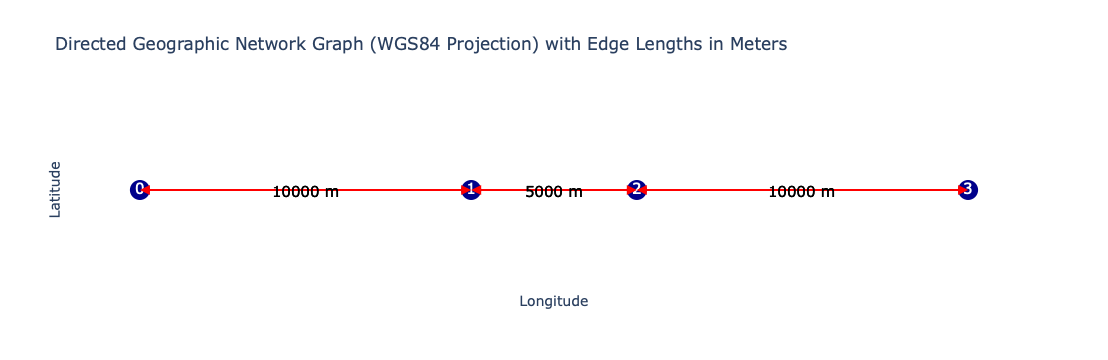

In [7]:
opentnsim.graph.plot_graph(FG)

#### 3. Run simulation

In [8]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [9]:
# start simpy environment
simulation_start = datetime.datetime(2024, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start
    
# add sites to graph
FG.edges[('1', '2')]["Resources"] = simpy.Resource(env, 1)

# add graph to environment
env.graph = FG

# create vessel from dict 
data_vessel = {
    "env": env,                                     # needed for simpy simulation, left empty for now
    "name": "Vessel",                               # required by Identifiable
    "geometry": env.graph.nodes['0']['geometry'],   # required by Locatable, left empty for now
    "route": nx.dijkstra_path(env.graph, "0", "3"), # required by Routeable, left empty for now
    "v": 1,                                         # required by Movable, 1 m/s to check if the distance is covered in the expected time
}  
vessel_1 = Vessel(**data_vessel)
vessel_1.name = 'Vessel 1'

vessel_2 = Vessel(**data_vessel)
vessel_2.name = 'Vessel 2'

# start the simulation
env.process(mission(env, vessel_1))
env.process(mission(env, vessel_2))
env.run()

#### 4. Inspect output
We can now inspect  the simulation output by inspecting the _vessel.logbook_. Note that the _Log_ mix-in was included when we added _Movable_. The _vessel.logbook_ keeps track of the moving activities of the vessel. For each discrete event OpenTNSim logs an event message, the start/stop time and the location. The _vessel.logbook_ is of type dict. For convenient inspection it can be loaded into a Pandas dataframe. 

In [10]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_1.logbook)

print("'{}' logbook data:".format(vessel_1.name))  
print('')

display(df)

'Vessel 1' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 0 to node 1 start,2024-01-01 00:00:00,0,POINT (0 0)
1,Sailing from node 0 to node 1 stop,2024-01-01 02:46:40,0,POINT (0.0898315284119522 0)
2,Sailing from node 1 to node 2 start,2024-01-01 02:46:40,0,POINT (0.0898315284119522 0)
3,Sailing from node 1 to node 2 stop,2024-01-01 04:10:00,0,POINT (0.1347472926179282 0)
4,Sailing from node 2 to node 3 start,2024-01-01 04:10:00,0,POINT (0.1347472926179282 0)
5,Sailing from node 2 to node 3 stop,2024-01-01 06:56:40,0,POINT (0.2245788210298804 0)


In [11]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_2.logbook)

print("'{}' logbook data:".format(vessel_2.name))  
print('')

display(df)

'Vessel 2' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 0 to node 1 start,2024-01-01 00:00:00,0,POINT (0 0)
1,Sailing from node 0 to node 1 stop,2024-01-01 02:46:40,0,POINT (0.0898315284119522 0)
2,Waiting to pass edge 1 - 2 start,2024-01-01 02:46:40,0,POINT (0.0898315284119522 0)
3,Waiting to pass edge 1 - 2 stop,2024-01-01 04:10:00,0,POINT (0.0898315284119522 0)
4,Sailing from node 1 to node 2 start,2024-01-01 04:10:00,0,POINT (0.0898315284119522 0)
5,Sailing from node 1 to node 2 stop,2024-01-01 05:33:20,0,POINT (0.1347472926179282 0)
6,Sailing from node 2 to node 3 start,2024-01-01 05:33:20,0,POINT (0.1347472926179282 0)
7,Sailing from node 2 to node 3 stop,2024-01-01 08:20:00,0,POINT (0.2245788210298804 0)


The inspection of the logbook data shows that Vessel moved from its origin (*Node 0*) to its destination (*Node 1*). The print statements show that the length of the route from *Node 0* to *Node 1* is exactly 100 km. At a given speed of 1 m/s the trip duration should be exactly 100000 seconds, as is indeed shown to be the case.

In [12]:
# TODO: naar de package verplaatsen - mogelijk in een log module plaatsen
def logbook_to_eventtable(objs):
    """Method to transform object logbook, that contains a list of activity start/stop logs, into a 'minimum event table'. 
    
    This method implements the basic 'event table' concept as proposed by Van der Werff:

    Van der Werff, S.E., F. Baart and M. van Koningsveld (2025). “Merging Multiple System Perspectives: The Key to 
    Effective Inland Shipping Emission-Reduction Policy Design.” Journal of Marine Science and engineering 13(4), 716. 
    https://doi.org/10.3390/jmse13040716 

    Van der Werff, S.E., S. Eppenga, A. van der Hout, F. Baart and M. van Koningsveld (2025). “Multi-perspective 
    nautical safety risk assessment of allisions with offshore wind parks.” Applied Ocean Research 158(2025),104564. 
    https://doi.org/10.1016/j.apor.2025.104564 

    For waterborne traffic travelling over a water transport network, a unique event is defined by a combination of: 
     - a unique vessel, 
     - that travels a specific section of the waterway, 
     - at a specific time.

    Parameters
    ----------
    objs: list
        list of OpenTNSim simulation objects that have log information

    Returns
    -------
    df: pandas.DataFrame
        dataframe that contains all events encapsulated in the obj.logbook attributes in the input list of objs
    """
    
    events = []
    for obj in objs:
        df = pd.DataFrame.from_dict(obj.logbook)
        for i in range(0, len(df), 2):
            activity = df.iloc[i]['Message'].replace(' start', '')
            
            start_time = df.iloc[i]['Timestamp']
            stop_time = df.iloc[i+1]['Timestamp']
            start_location = df.iloc[i]['Geometry']
            stop_location = df.iloc[i+1]['Geometry']
            
            duration_seconds = (stop_time - start_time).total_seconds()
            distance_meters = opentnsim.graph.calculate_distance(start_location, stop_location)
            
            events.append({
                'object id': obj.id,
                'object name': obj.name,
                'activity name': activity,
                'start location': start_location,
                'stop location': stop_location,
                'start time': start_time,
                'stop time': stop_time,
                'distance (m)': distance_meters,
                'duration (s)': duration_seconds,
            })
        
    # Final DataFrame
    df = pd.DataFrame(events)
    
    return df

In [13]:
df_eventtable = logbook_to_eventtable([vessel_1, vessel_2])
df_eventtable

,object id,object name,activity name,start location,stop location,start time,stop time,distance (m),duration (s)
0,ea1f3d1b-b221-4b90-9bd1-9402b6b4fdc6,Vessel 1,Sailing from node 0 to node 1,POINT (0 0),POINT (0.0898315284119522 0),2024-01-01 00:00:00,2024-01-01 02:46:40,10000.0,10000.0
1,ea1f3d1b-b221-4b90-9bd1-9402b6b4fdc6,Vessel 1,Sailing from node 1 to node 2,POINT (0.0898315284119522 0),POINT (0.1347472926179282 0),2024-01-01 02:46:40,2024-01-01 04:10:00,5000.0,5000.0
2,ea1f3d1b-b221-4b90-9bd1-9402b6b4fdc6,Vessel 1,Sailing from node 2 to node 3,POINT (0.1347472926179282 0),POINT (0.2245788210298804 0),2024-01-01 04:10:00,2024-01-01 06:56:40,10000.0,10000.0
3,e3836f25-2ad5-4b04-aab9-ab2c80cf2c9b,Vessel 2,Sailing from node 0 to node 1,POINT (0 0),POINT (0.0898315284119522 0),2024-01-01 00:00:00,2024-01-01 02:46:40,10000.0,10000.0
4,e3836f25-2ad5-4b04-aab9-ab2c80cf2c9b,Vessel 2,Waiting to pass edge 1 - 2,POINT (0.0898315284119522 0),POINT (0.0898315284119522 0),2024-01-01 02:46:40,2024-01-01 04:10:00,0.0,5000.0
5,e3836f25-2ad5-4b04-aab9-ab2c80cf2c9b,Vessel 2,Sailing from node 1 to node 2,POINT (0.0898315284119522 0),POINT (0.1347472926179282 0),2024-01-01 04:10:00,2024-01-01 05:33:20,5000.0,5000.0
6,e3836f25-2ad5-4b04-aab9-ab2c80cf2c9b,Vessel 2,Sailing from node 2 to node 3,POINT (0.1347472926179282 0),POINT (0.2245788210298804 0),2024-01-01 05:33:20,2024-01-01 08:20:00,10000.0,10000.0


In [14]:
def generate_vessel_gantt_chart(df_eventtable: pd.DataFrame):
    """Method to generate a Gantt chart from a vessel activity log DataFrame.

    This method visualizes the activity timeline of vessels by combining vessel names and activity types into a single label,
    and plotting them using Plotly Express's timeline chart. 

    Parameters
    ----------
    df_eventtable : pandas.DataFrame
        DataFrame containing columns 'object name', 'activity name', 'start time', and 'stop time' representing vessel activity logs.

    Returns
    -------
    fig : plotly.graph_objects.Figure
        A Plotly figure object representing the Gantt chart of vessel activities.
    """
    
    # Add vessel name to activity label
    df_eventtable['activity label'] = df_eventtable['object name'] + ' - ' + df_eventtable['activity name']

    # Create the Gantt chart
    fig = px.timeline(
        df_eventtable,
        x_start="start time",
        x_end="stop time",
        y="activity label",
        color="object name",
        title="Gantt chart of logged events"
    )

    # Reverse the Y-axis to match Gantt chart style
    fig.update_yaxes(autorange="reversed")

    # Customize layout
    fig.update_layout(
        xaxis_title="Time",
        yaxis_title="Activity (with Vessel)",
        legend_title="Vessel",
        margin=dict(l=20, r=20, t=40, b=20)
    )

    return fig

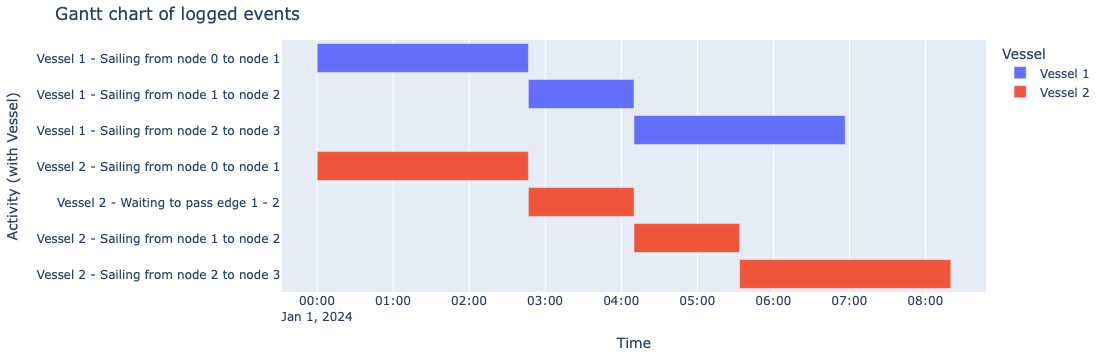

In [16]:
generate_vessel_gantt_chart(df_eventtable)

The inspection of the logbook data shows that the mission of the Vessel, resulted in four cycles where loading - sailing - unloading - sailing were executed in a sequence. The sites had a capacity of 100, and the Vessel a capacity of 30. It can be seen that the last cycle the loading and unloading take less time because the Vessel sailed only partially filled.